# Sensitivity Analysis of Departure Policy Threshold $c^*$

This notebook performs a numerical sensitivity analysis on the departure (replacement) policy threshold.
Under exponential baseline hazard, the optimal replacement policy is a control limit: **replace iff** $\theta^\top X \geq c^*$.

We investigate how $c^*$ varies with:
- $R$ — replacement cost
- $F$ — failure cost
- $h$ — holding cost rate
- $\lambda$ — baseline hazard rate

For each pair of parameters, we run value iteration on a 2D grid and visualize the threshold landscape.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from itertools import combinations
import pickle
import os
import sys
sys.path.insert(0, '../src')

import raas.config as config
from raas.utils import get_perfect_degradation_learner
from tqdm.notebook import tqdm
from utils import get_scalar_threshold, extract_thresholds_by_t

import logging
logging.basicConfig(level=logging.WARNING)

np.set_printoptions(suppress=True)

In [2]:
# Default parameter values
DEFAULTS = {
    'R': config.mdp_params['replacement_cost'],       # 1.5
    'F': config.mdp_params['failure_cost'],            # 0.75
    'h': config.mdp_params['holding_cost_rate'],       # 0.02
    'lam': config.LAMBDA_VAL,                          # 0.001
}

# Sweep ranges (0.25x to 4x of default)
N_POINTS = 15
RANGES = {
    'R': np.linspace(0.25 * DEFAULTS['R'], 4 * DEFAULTS['R'], N_POINTS),
    'F': np.linspace(0.25 * DEFAULTS['F'], 4 * DEFAULTS['F'], N_POINTS),
    'h': np.linspace(0.25 * DEFAULTS['h'], 4 * DEFAULTS['h'], N_POINTS),
    'lam': np.linspace(0.25 * DEFAULTS['lam'], 4 * DEFAULTS['lam'], N_POINTS),
}

# Pretty labels for plotting
PARAM_LABELS = {
    'R': r'Replacement Cost $R$',
    'F': r'Failure Cost $F$',
    'h': r'Holding Cost Rate $h$',
    'lam': r'Baseline Hazard $\lambda$',
}

# Value iteration settings (adjust for speed vs accuracy tradeoff)
VI_SAMPLE_SIZE = 300000
VI_ITERATIONS = 200

print('Parameter ranges:')
for name, vals in RANGES.items():
    print(f'  {name}: [{vals[0]:.6f}, {vals[-1]:.6f}] ({len(vals)} points), default={DEFAULTS[name]}')

Parameter ranges:
  R: [0.375000, 6.000000] (15 points), default=1.5
  F: [0.300000, 4.800000] (15 points), default=1.2
  h: [0.005000, 0.080000] (15 points), default=0.02
  lam: [0.000250, 0.004000] (15 points), default=0.001


## Verification of $t$-Independence

Under exponential baseline hazard ($\lambda_0(t) = \lambda$), Proposition 1 shows that
the active time $t$ is irrelevant for the hazard rate. Therefore, $c^*$ should be constant across all $t$ grid points.
We verify this numerically with the default parameters.

INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        100 steps up to 15.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 76.01
INFO:root:  - Active Time (t)                50 steps up to 760.09
INFO:root:Pre-computing dynamics (100x50x50x50 = 12,500,000 4D states, vs 625,000,000 original 5D)...
INFO:root:  Sampling 300000 customers for expectation weights...


Training oracle policy with default parameters...


INFO:root:  18489 unique customer tuples (from 300000 samples)
INFO:root:  Computing Delta_Lambda (2D)...
INFO:root:  Computing P_survival (4D)...
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
INFO:root:  Computing next-state indices (2D)...
INFO:root:Pre-computation complete.
INFO:root:
Starting Value Iteration (optimized) — 625,000,000 states, float32, fused kernel...
INFO:root:Iteration 10/200 | Max Delta: 0.104234
INFO:root:Iteration 20/200 | Max Delta: 0.070930
INFO:root:Iteration 30/200 | Max Delta: 0.055156
INFO:root:Iteration 40/200 | Max Delta: 0.044846
INFO:root:Iteration 50/200 | Max Delta: 0.036643
INFO:root:Iteration 60/200 | Max Delta: 0.030396
INFO:root:Iteration 70/200 | Max Delta: 0.024987
INFO:root:Iteration 80/200 | Max Delta: 0.020984
INFO:root:Iteration 90/200 | Max Delta: 0.016931
INFO:root:Iteration 100/200 | Max Delta: 0.013972
INFO:root:Iteration 110/200 | Max Delta: 0.012041
INFO:root:Iteration 120/200 | Max D

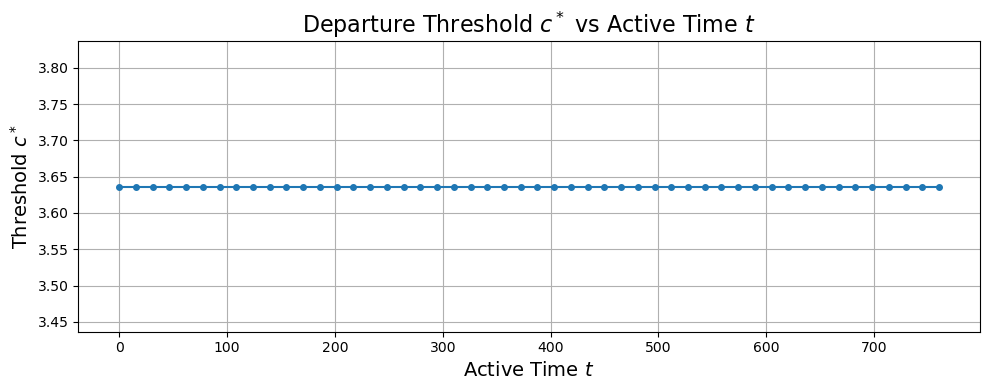


Default c* = 3.6364
Range across t: [3.6364, 3.6364]
Std dev across t: 0.000000


In [3]:
# Train with default parameters
print('Training oracle policy with default parameters...')
logging.getLogger().setLevel(logging.INFO)
_, dpagent_default, _ = get_perfect_degradation_learner(
    sample_size=VI_SAMPLE_SIZE,
    iterations=VI_ITERATIONS
)
logging.getLogger().setLevel(logging.WARNING)

# Extract thresholds for each t
thresholds_by_t = extract_thresholds_by_t(dpagent_default)
t_grid = dpagent_default.grids[4]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, thresholds_by_t, 'o-', markersize=4)
ax.set_xlabel('Active Time $t$', fontsize=14)
ax.set_ylabel(r'Threshold $c^*$', fontsize=14)
ax.set_title(r'Departure Threshold $c^*$ vs Active Time $t$', fontsize=16)
ax.grid(True)
plt.tight_layout()
plt.show()

c_star_default = get_scalar_threshold(dpagent_default)
print()
print(f'Default c* = {c_star_default:.4f}')
print(f'Range across t: [{thresholds_by_t.min():.4f}, {thresholds_by_t.max():.4f}]')
print(f'Std dev across t: {np.std(thresholds_by_t):.6f}')

## Pairwise Sensitivity Analysis

For each of the $\binom{4}{2} = 6$ pairs of parameters, we run value iteration over a 2D grid
and record the departure threshold $c^*$. Non-varied parameters are held at their default values.

In [4]:
def build_params(overrides):
    """Build mdp_params dict and lambda value from a dict of overrides."""
    mdp = deepcopy(config.mdp_params)
    lam = config.LAMBDA_VAL

    for name, val in overrides.items():
        if name == 'R':
            mdp['replacement_cost'] = val
        elif name == 'F':
            mdp['failure_cost'] = val
        elif name == 'h':
            mdp['holding_cost_rate'] = val
        elif name == 'lam':
            lam = val

    return mdp, lam


def run_pairwise_sensitivity(param1_name, param1_values, param2_name, param2_values,
                              sample_size=VI_SAMPLE_SIZE, iterations=VI_ITERATIONS):
    """Run grid search over a pair of parameters, return threshold matrix.

    Returns:
        threshold_matrix: shape (len(param1_values), len(param2_values))
            threshold_matrix[i, j] = c* when param1=param1_values[i], param2=param2_values[j]
    """
    n1, n2 = len(param1_values), len(param2_values)
    threshold_matrix = np.full((n1, n2), np.nan)

    total = n1 * n2
    with tqdm(total=total, desc=f'{param1_name} vs {param2_name}') as pbar:
        for i, v1 in enumerate(param1_values):
            for j, v2 in enumerate(param2_values):
                mdp, lam = build_params({param1_name: v1, param2_name: v2})
                _, dpagent, _ = get_perfect_degradation_learner(
                    sample_size=sample_size,
                    iterations=iterations,
                    mdp_params=mdp,
                    baseline_hazard_lambda=lam
                )
                threshold_matrix[i, j] = get_scalar_threshold(dpagent)
                pbar.update(1)

    return threshold_matrix

In [5]:
param_names = ['R', 'F', 'h', 'lam']
pairs = list(combinations(param_names, 2))
results = {}

for p1, p2 in pairs:
    save_path = f'../data/sensitivity_{p1}_{p2}.pkl'

    # Skip if already computed
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            data = pickle.load(f)
        results[(p1, p2)] = data['matrix']
        print(f'Loaded existing results for {p1} vs {p2} from {save_path}')
        continue

    print()
    print('=' * 50)
    print(f'Running sensitivity: {p1} vs {p2}')
    print('=' * 50)

    threshold_mat = run_pairwise_sensitivity(p1, RANGES[p1], p2, RANGES[p2])
    results[(p1, p2)] = threshold_mat

    # Save intermediate results
    with open(save_path, 'wb') as f:
        pickle.dump({
            'matrix': threshold_mat,
            'axis1_name': p1, 'axis1_values': RANGES[p1],
            'axis2_name': p2, 'axis2_values': RANGES[p2],
        }, f)
    print(f'Saved to {save_path}')

print()
print('All pairwise analyses complete!')

Loaded existing results for R vs F from ../data/sensitivity_R_F.pkl
Loaded existing results for R vs h from ../data/sensitivity_R_h.pkl
Loaded existing results for R vs lam from ../data/sensitivity_R_lam.pkl
Loaded existing results for F vs h from ../data/sensitivity_F_h.pkl
Loaded existing results for F vs lam from ../data/sensitivity_F_lam.pkl
Loaded existing results for h vs lam from ../data/sensitivity_h_lam.pkl

All pairwise analyses complete!


## Visualization

Heatmaps showing $c^*$ as a function of each parameter pair.
Red crosshairs mark the default parameter values.

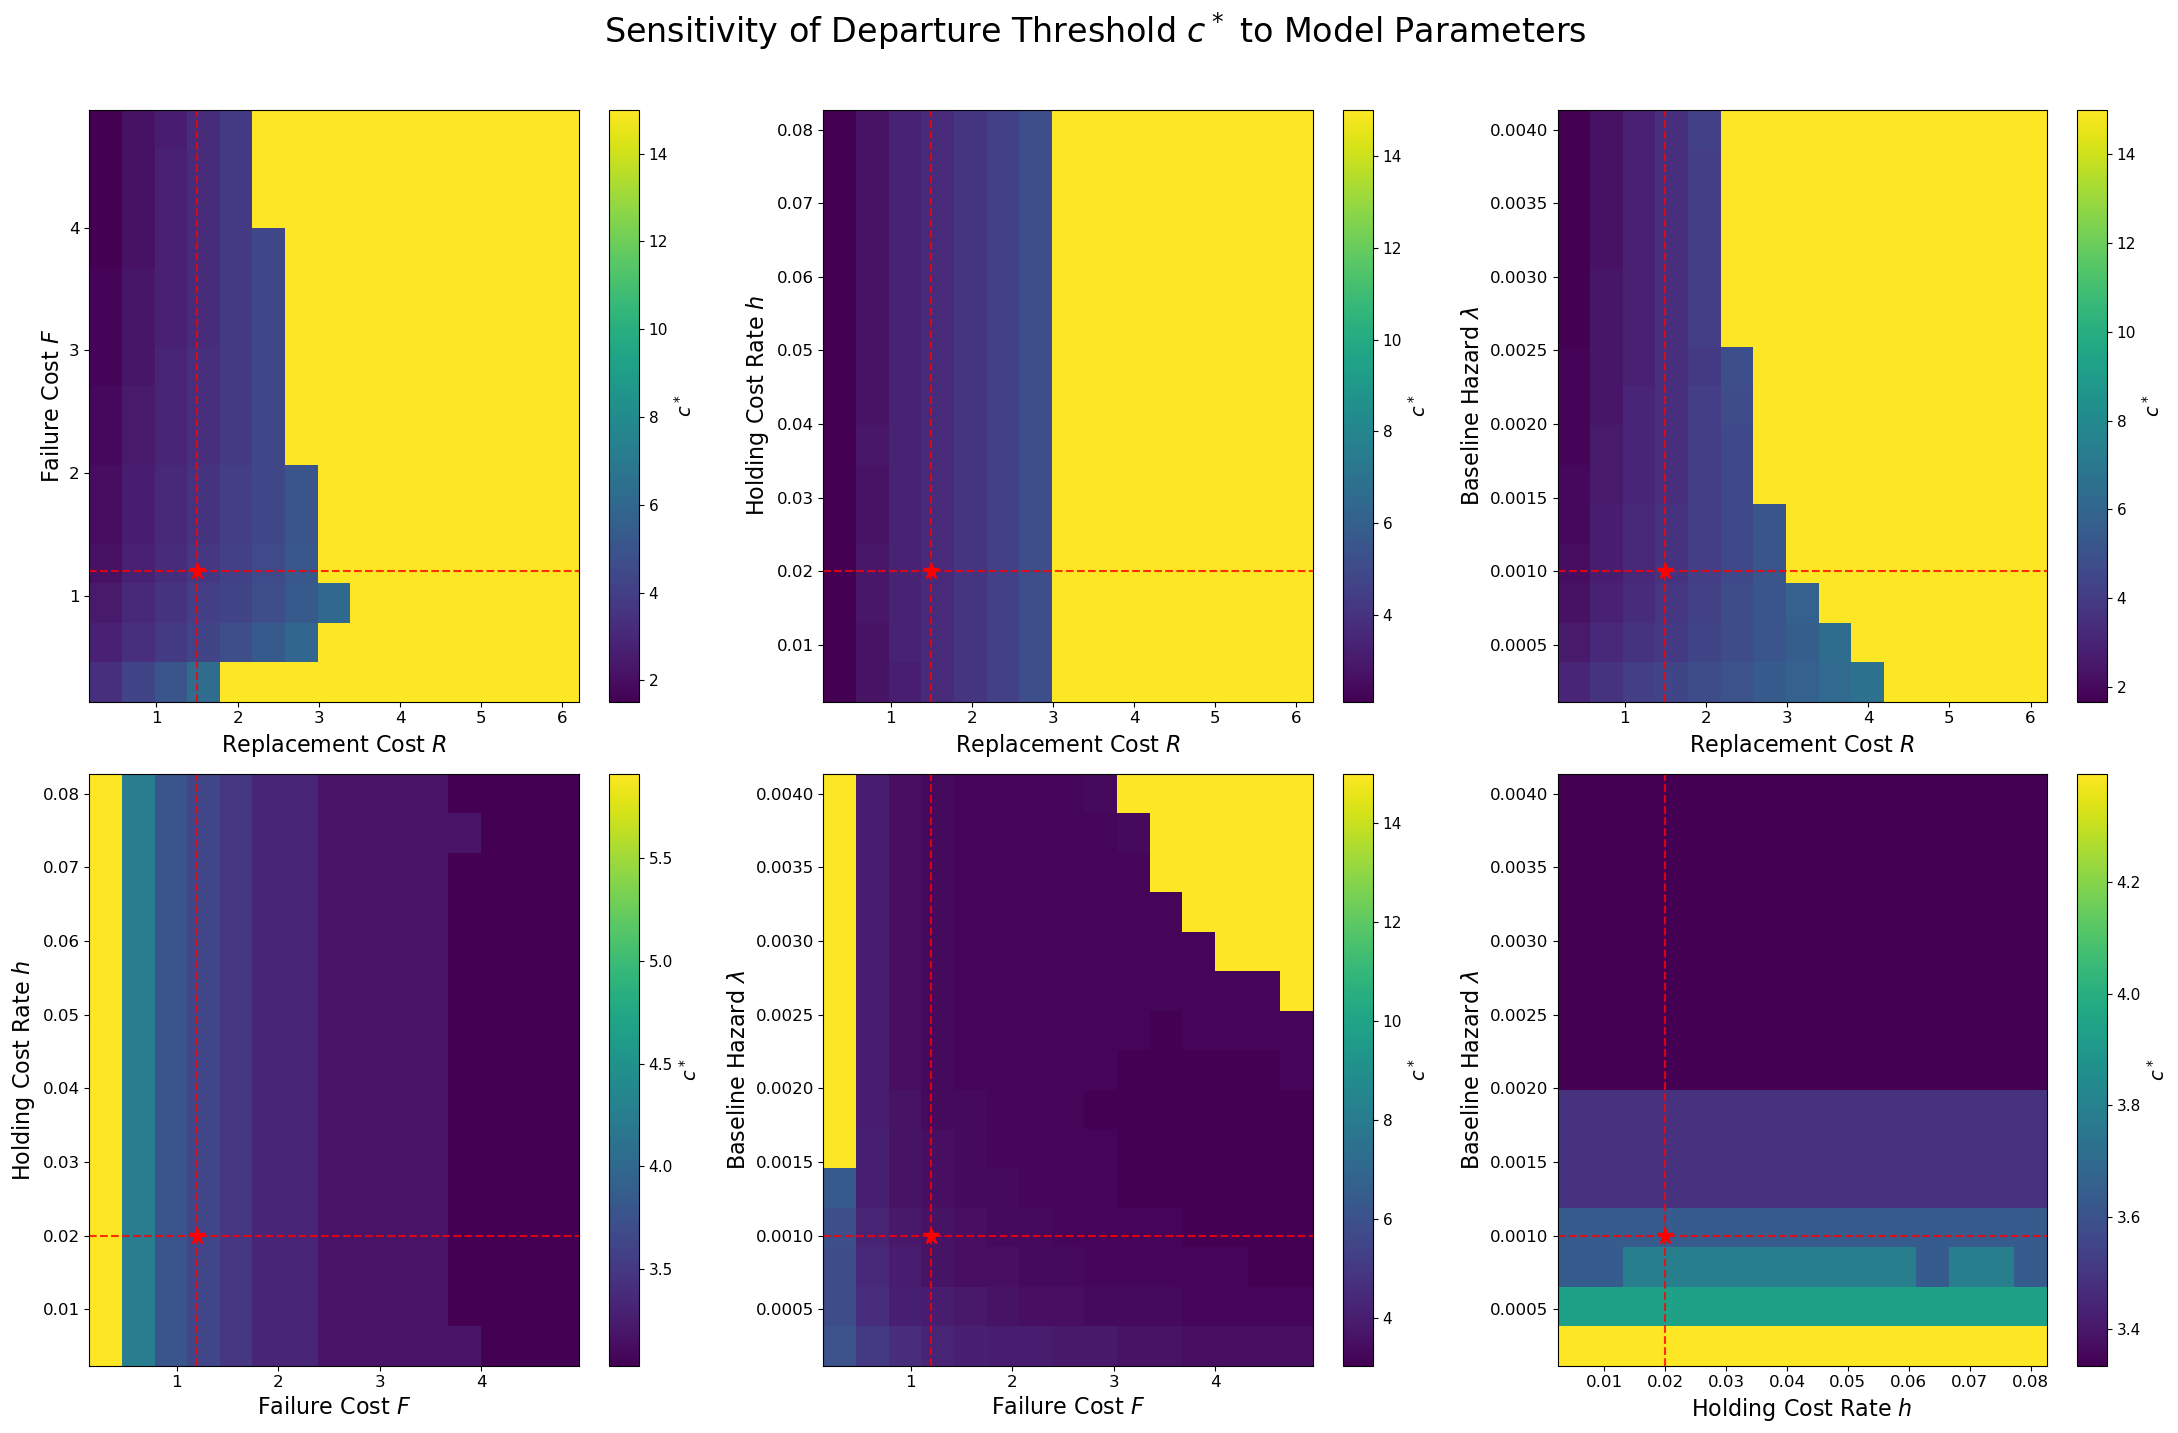

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes_flat = axes.flatten()

for idx, (p1, p2) in enumerate(pairs):
    ax = axes_flat[idx]
    mat = results[(p1, p2)]

    X, Y = np.meshgrid(RANGES[p1], RANGES[p2])
    pcm = ax.pcolormesh(X, Y, mat.T, cmap='viridis', shading='auto')

    # # Contour lines
    # try:
    #     ax.contour(
    #         RANGES[p1], RANGES[p2], mat.T,
    #         levels=8, colors='white', linewidths=0.5, alpha=0.6
    #     )
    # except ValueError:
    #     pass  # Skip contours if data is constant

    # Mark defaults
    ax.axvline(DEFAULTS[p1], color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.axhline(DEFAULTS[p2], color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.plot(DEFAULTS[p1], DEFAULTS[p2], 'r*', markersize=12)

    ax.set_xlabel(PARAM_LABELS[p1], fontsize=16)
    ax.set_ylabel(PARAM_LABELS[p2], fontsize=16)
    ax.tick_params(labelsize=12)

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r'$c^*$', fontsize=14)
    cbar.ax.tick_params(labelsize=11)

fig.suptitle(r'Sensitivity of Departure Threshold $c^*$ to Model Parameters', fontsize=24, y=1.02)
plt.tight_layout()
plt.savefig('../figures/sensitivity_departure_threshold.pdf', bbox_inches='tight')
plt.show()

## Load Saved Results

If the grid search was run previously, you can load the saved pickle files and re-plot without re-running.

In [7]:
# Uncomment to load previously saved results instead of re-running
# param_names = ['R', 'F', 'h', 'lam']
# pairs = list(combinations(param_names, 2))
# results = {}
# for p1, p2 in pairs:
#     load_path = f'../data/sensitivity_{p1}_{p2}.pkl'
#     with open(load_path, 'rb') as f:
#         data = pickle.load(f)
#     results[(p1, p2)] = data['matrix']
#     print(f'Loaded {p1} vs {p2} from {load_path}')